#0. Introduzione
In questo notebook vengono addestrati e valutati diversi modelli di classificazione, con l’obiettivo di identificare quello più efficace nella predizione delle classi target in uno studio sui disturbi neuropsichiatrici. L’obiettivo principale è massimizzare la balanced accuracy, in quanto il dataset presenta un marcato sbilanciamento tra le classi.

La balanced accuracy, in particolare, calcola la media del recall per ogni classe, dando lo stesso peso a tutte, anche se sono sbilanciate.

Il dataset è già stato oggetto di analisi esplorativa e preprocessamento in una fase precedente, pertanto le sue caratteristiche non vengono qui descritte nel dettaglio.

Per l’addestramento dei modelli sono utilizzate tutte le features eccetto quelle che terminano con _PG. Al fine di garantire una validazione corretta e priva di data leakage tra i fold, è stata costruita una pipeline di preprocessing che include: imputazione dei valori mancanti, codifica delle variabili categoriche e normalizzazione delle variabili numeriche.

Il codice è progettato per essere flessibile e adattabile sia a problemi di classificazione binaria che multiclasse.

#1. Caricamento librerie
In questa sezione sono state caricate tutte le librerie utilizzate.

In [1]:
# Installazione librerie esterne
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.0 MB/s eta 0:00:00


In [2]:
# Librerie per la manipolazione dei dati
import pandas as pd
import numpy as np

# Librerie per la visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# Librerie per il preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.pipeline import Pipeline

# Librerie per la selezione e validazione del modello
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Librerie per la valutazione del modello
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    make_scorer
)

# Librerie per modelli di classificazione
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier, RandomForestRegressor
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

# Librerie per costruzione pipeline e bilanciamento classi
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# Librerie per gestione di warnings
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

#2. Definizione funzioni per la pipeline e per la valutazione dei modelli
Il codice seguente definisce una serie di trasformatori personalizzati, una pipeline di modellazione supervisionata e una funzione di valutazione delle performance, con particolare attenzione alla gestione intelligente dei valori mancanti e alla corretta validazione del modello.

L’uso di una pipeline assicura che tutte le operazioni di preprocessing (come imputazione, encoding, scaling, bilanciamento, ecc.) vengano eseguite in modo coerente sia durante l’addestramento che nella fase di test o validazione incrociata. Questo approccio previene errori comuni, come il data leakage, ovvero l’uso involontario di informazioni del test set durante il training, che potrebbe produrre metriche artificialmente alte e non realistiche.

In particolare, viene definito un trasformatore personalizzato per l’imputazione dei valori mancanti nelle colonne _ESITO:

- CategoricalESITOImputer.

La funzione build_pipeline restituisce una pipeline ImbPipeline composta da:

- Imputazione intelligente (categorie e numeri),

- Preprocessing (scaling, encoding, ecc.),

- Bilanciamento delle classi con SMOTETomek,

- Classificatore supervisionato finale (es. RandomForest, SVM, ecc.).

Infine, la funzione evaluate_model fornisce una valutazione completa delle prestazioni del modello. Include:

- Visualizzazione delle metriche di validazione incrociata ottimali ottenute tramite ricerca degli iperparametri,

- Calcolo di metriche sul test set: Accuratezza Bilanciata, F1-macro e ROC AUC,

- Report di classificazione dettagliato e matrice di confusione visualizzata tramite heatmap.

Tutte le funzioni sono compatibili con problemi di classificazione binaria e multiclasse.

In [3]:
# Classe per la gestione dei valori mancanti nelle colonne _ESITO con la moda
class CategoricalESITOImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.esito_cols = [c for c in X.columns if c.endswith('_ESITO')]
        self.imputers = {
            col: SimpleImputer(strategy='most_frequent').fit(X[[col]])
            for col in self.esito_cols
        }
        return self

    def transform(self, X):
        check_is_fitted(self, 'imputers')
        X = X.copy()
        for col, imputer in self.imputers.items():
            if col in X.columns:
                X[[col]] = imputer.transform(X[[col]])
        return X

# Funzione per la costruzione della pipeline completa
def build_pipeline(classifier):
    return ImbPipeline(steps=[
        ('categorical_esito_imputer', CategoricalESITOImputer()),
        ('preprocessor', preprocessor),
        ('sampling', SMOTETomek(random_state=42)),
        ('classifier', classifier)
    ])

# Funzione per la valutazione dei modelli
def evaluate_model(search, X_test, y_test, class_labels, le=None, is_multiclass=False):
    best_model = search.best_estimator_

    if le is not None:
        y_test_encoded = le.transform(y_test)
        y_pred = best_model.predict(X_test)
        y_pred_labels = le.inverse_transform(y_pred)
        y_proba = best_model.predict_proba(X_test)
        y_test_eval = y_test_encoded
        y_pred_eval = y_pred
        y_pred_print = y_pred_labels
    else:
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)
        y_test_eval = y_test
        y_pred_eval = y_pred
        y_pred_print = y_pred

    print("\n=== Best cross-validation scores ===")
    best_idx = search.best_index_
    for key in search.scoring:
        score = search.cv_results_[f'mean_test_{key}'][best_idx]
        print(f"{key}: {score:.4f}")

    print("\nBest parameters:", search.best_params_)

    test_bal_acc = balanced_accuracy_score(y_test_eval, y_pred_eval)
    test_f1 = f1_score(y_test_eval, y_pred_eval, average='macro')

    # ROC AUC
    if is_multiclass:
        test_roc_auc = roc_auc_score(y_test_eval, y_proba, multi_class='ovr', average='macro')
    else:
        test_roc_auc = roc_auc_score(y_test_eval, y_proba[:, 1])  # solo la colonna positiva

    print("\n=== Test set scores ===")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"F1 Score (macro): {test_f1:.4f}")
    print(f"ROC AUC: {test_roc_auc:.4f}")

    print("\nClassification report:\n", classification_report(y_test, y_pred_print))

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred_print, labels=class_labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

#3. Importazione del dataset, eliminazione delle colonne _PG e suddivisione in training e test set
In questa sezione viene caricato il dataset, già sottoposto ad una prima fase di pre-processing.
Dopo aver individuato la variabile target *Patologia* ed eliminato le colonne _PG, i cui valori non sono stati utilizzati per addestrare il modello, il dataset viene suddiviso in un training set (80%) e un test set (20%) per consentire l'allenamento e la valutazione del modello.

In [4]:
# Caricamento dataset
file_path = 'df_3_pg_esito.csv'
df = pd.read_csv(file_path)

In [5]:
# Eliminazione colonne '_PG'
df = df.drop(columns=[col for col in df.columns if col.endswith('_PG')])
df.columns

Index(['Scolarita', 'Eta', 'Sesso', 'MMSE_ESITO', 'CLOCKTEST_ESITO',
       'COPIAFIGURAREY_ESITO', 'PAROLEREYIMM_ESITO', 'PAROLEREYDIFF_ESITO',
       'MEMORIAFIGURAREY_ESITO', 'FLUENZAVERBFON_ESITO',
       'TESTMATRICIATTENTIVE_ESITO', 'Patologia'],
      dtype='object')

In [6]:
# Split dataset
X = df.drop('Patologia', axis=1)
y = df['Patologia']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

#4. Selezione delle feature e definizione del preprocessing
In questa sezione vengono individuati e suddivisi i gruppi di features, da utilizzare per l'addestramento dei modelli, in base alla loro natura:
- Variabili numeriche continue (Eta, Scolarita),
- Variabili categoriche (Sesso, _ESITO).

Successivamente viene costruito un preprocessor basato su ColumnTransformer, che applica trasformazioni specifiche per ciascun gruppo di feature:

- Imputazione e standardizzazione per le variabili numeriche,
- Imputazione e codifica one-hot per le variabili categoriche.

Infine, si identifica automaticamente se il problema di classificazione è binario o multiclasse, in base al numero di classi presenti nel training set.

In [7]:
# Selezione feature
numeric_features = ['Eta', 'Scolarita']
esito_features = [col for col in X.columns if col.endswith('_ESITO')]
categorical_features = ['Sesso'] + esito_features

# Costruzione preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
], remainder='passthrough')

In [8]:
# Controllo se il problema è binario o multiclasse
unique_classes = np.unique(y_train)
n_classes = len(unique_classes)
is_multiclass = n_classes > 2

#5. Definizione dei modelli e tuning degli iperparametri

In questa sezione viene definito un dizionario che contiene 8 modelli di classificazione supervisionata, ciascuno associato a una griglia di iperparametri da ottimizzare tramite GridSearchCV.

Per ogni modello:

- Viene costruita una pipeline che integra il preprocessing, il bilanciamento delle classi e il classificatore.

- Viene eseguita una ricerca a griglia con validazione incrociata stratificata a 5 fold, utilizzando due metriche: balanced_accuracy e f1_weighted.

- I modelli XGBoost e CatBoost sono inizializzati dinamicamente in base al tipo di problema (binario o multiclasse).

- Il modello ottimale (in base alla balanced_accuracy) viene infine valutato sul test set tramite la funzione evaluate_model.

Questo approccio consente un confronto sistematico tra diversi modelli anche in presenza di classi sbilanciate, offrendo robustezza e generalizzazione.

Modelli utilizzati:

- WeightedKNN: una variante di KNN che pondera la distanza (i "vicini più vicini" contano di più), più robusta a rumore e classi sbilanciate.

- DecisionTree: albero di decisione classico con supporto a bilanciamento classi e controllo della complessità.

- BalancedRandomForest: estensione della Random Forest con bilanciamento automatico dei campioni minoritari.

- SVM: support vector machine con possibilità di kernel non lineari e bilanciamento automatico.

- ExtraTrees: insieme di alberi decisionali che usa più casualità per evitare l'overfitting.

- LGBM: LightGBM, un algoritmo gradient boosting efficiente, adatto anche a dataset ampi e con molte features.

- CatBoost: algoritmo di boosting che funziona bene con dati misti e gestisce bene le variabili categoriche.

- XGBoost: boosting molto performante e diffuso, altamente configurabile, ottimo per molti problemi di classificazione.


=== Addestramento modello: WeightedKNN ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6386
f1_macro: 0.6243

Best parameters: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 9, 'classifier__p': 2}

=== Test set scores ===
Balanced Accuracy: 0.6093
F1 Score (macro): 0.5829
ROC AUC: 0.7637

Classification report:
                         precision    recall  f1-score   support

  Assenza di patologia       0.90      0.72      0.80        60
Disturbo non Alzheimer       0.33      0.44      0.38        18
 Malattia di Alzheimer       0.50      0.67      0.57        18

              accuracy                           0.66        96
             macro avg       0.58      0.61      0.58        96
          weighted avg       0.72      0.66      0.68        96



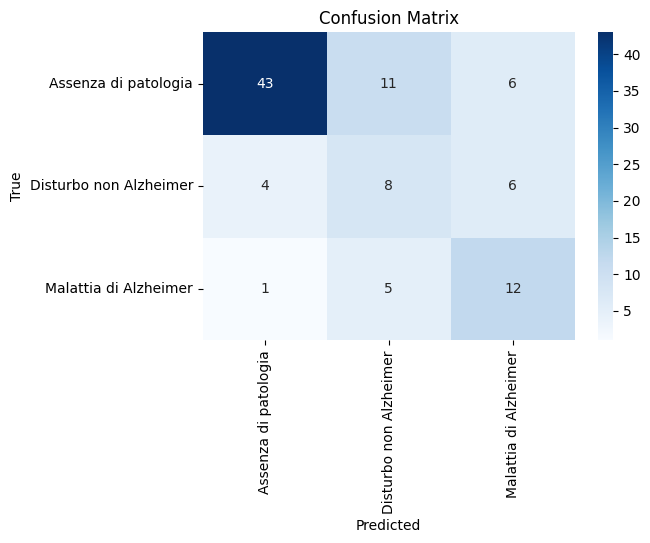

----------------------------------------------------------------------------------------------------

=== Addestramento modello: DecisionTree ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6913
f1_macro: 0.6765

Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 15}

=== Test set scores ===
Balanced Accuracy: 0.6074
F1 Score (macro): 0.6083
ROC AUC: 0.7378

Classification report:
                         precision    recall  f1-score   support

  Assenza di patologia       0.84      0.77      0.80        60
Disturbo non Alzheimer       0.33      0.50      0.40        18
 Malattia di Alzheimer       0.71      0.56      0.62        18

              accuracy                           0.68        96
             macro avg       0.63      0.61      0.61        96
          weighted avg       0.72      0.68      0.69   

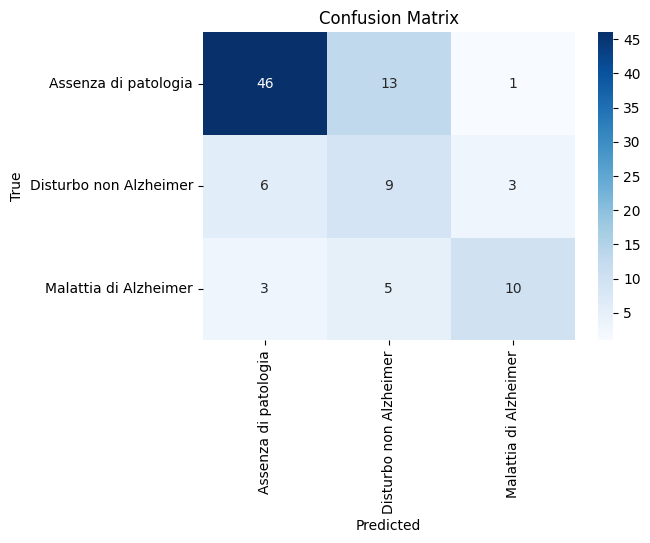

----------------------------------------------------------------------------------------------------

=== Addestramento modello: BalancedRandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6718
f1_macro: 0.6782

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}

=== Test set scores ===
Balanced Accuracy: 0.6648
F1 Score (macro): 0.6706
ROC AUC: 0.8393

Classification report:
                         precision    recall  f1-score   support

  Assenza di patologia       0.85      0.88      0.87        60
Disturbo non Alzheimer       0.53      0.50      0.51        18
 Malattia di Alzheimer       0.65      0.61      0.63        18

              accuracy                           0.76        96
             macro avg       0.68      0.66      0.67        96
          weighted avg       0.75      0.76    

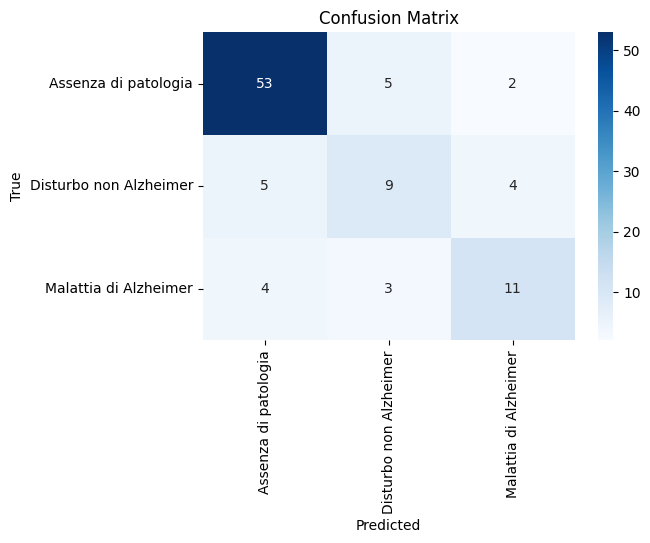

----------------------------------------------------------------------------------------------------

=== Addestramento modello: SVM ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6581
f1_macro: 0.6372

Best parameters: {'classifier__C': 0.1, 'classifier__degree': 3, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly'}

=== Test set scores ===
Balanced Accuracy: 0.5926
F1 Score (macro): 0.5647
ROC AUC: 0.8045

Classification report:
                         precision    recall  f1-score   support

  Assenza di patologia       0.89      0.83      0.86        60
Disturbo non Alzheimer       0.33      0.22      0.27        18
 Malattia di Alzheimer       0.46      0.72      0.57        18

              accuracy                           0.70        96
             macro avg       0.56      0.59      0.56        96
          weighted avg       0.71      0.70      0.69        96



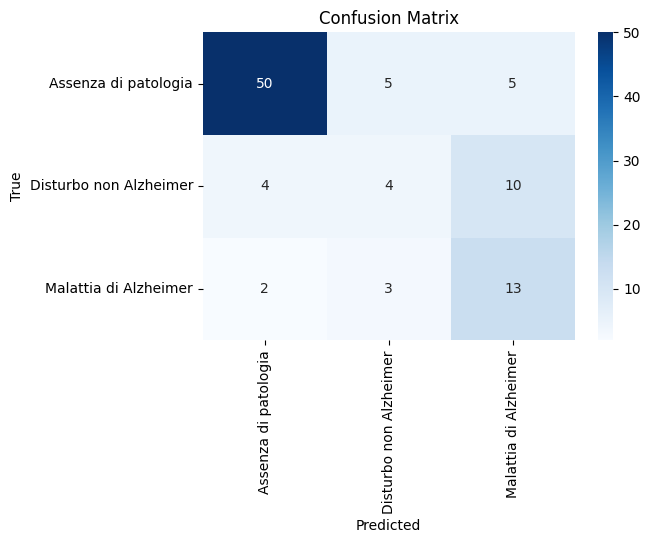

----------------------------------------------------------------------------------------------------

=== Addestramento modello: ExtraTrees ===
Fitting 5 folds for each of 144 candidates, totalling 720 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.6454
f1_macro: 0.6422

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

=== Test set scores ===
Balanced Accuracy: 0.6222
F1 Score (macro): 0.6246
ROC AUC: 0.8457

Classification report:
                         precision    recall  f1-score   support

  Assenza di patologia       0.85      0.87      0.86        60
Disturbo non Alzheimer       0.53      0.50      0.51        18
 Malattia di Alzheimer       0.50      0.50      0.50        18

              accuracy                           0.73        96
             macro avg       0.63      0.62      0.62        96
          weighted avg       0.73      0.73      0.73    

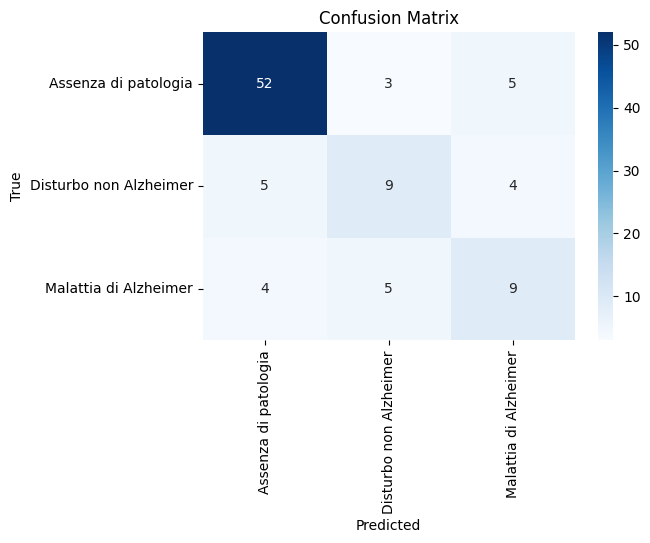

----------------------------------------------------------------------------------------------------

=== Addestramento modello: LGBM ===
Fitting 5 folds for each of 60 candidates, totalling 300 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.7109
f1_macro: 0.7130

Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}

=== Test set scores ===
Balanced Accuracy: 0.6852
F1 Score (macro): 0.6844
ROC AUC: 0.8089

Classification report:
                         precision    recall  f1-score   support

  Assenza di patologia       0.86      0.83      0.85        60
Disturbo non Alzheimer       0.45      0.56      0.50        18
 Malattia di Alzheimer       0.75      0.67      0.71        18

              accuracy                           0.75        96
             macro avg       0.69      0.69      0.68        96
          weighted avg       0.76      0.75      0.76        96



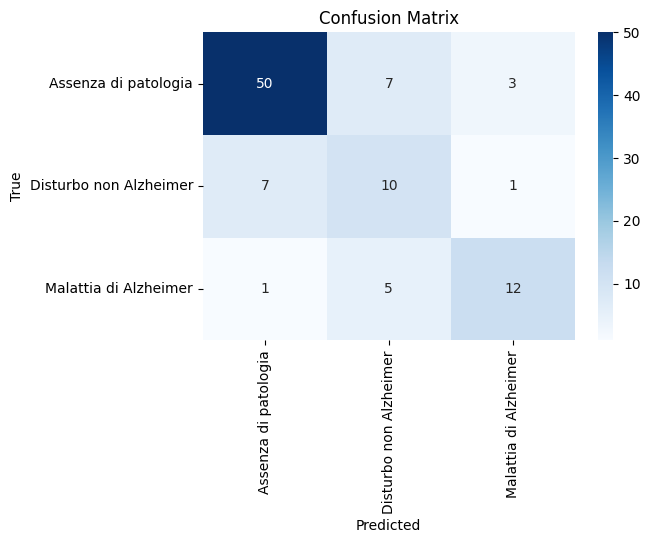

----------------------------------------------------------------------------------------------------

=== Addestramento modello: CatBoost ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.7179
f1_macro: 0.7106

Best parameters: {'classifier__depth': 4, 'classifier__iterations': 300, 'classifier__learning_rate': 0.05}

=== Test set scores ===
Balanced Accuracy: 0.7093
F1 Score (macro): 0.6983
ROC AUC: 0.8602

Classification report:
                         precision    recall  f1-score   support

  Assenza di patologia       0.91      0.85      0.88        60
Disturbo non Alzheimer       0.48      0.56      0.51        18
 Malattia di Alzheimer       0.68      0.72      0.70        18

              accuracy                           0.77        96
             macro avg       0.69      0.71      0.70        96
          weighted avg       0.79      0.77      0.78        96



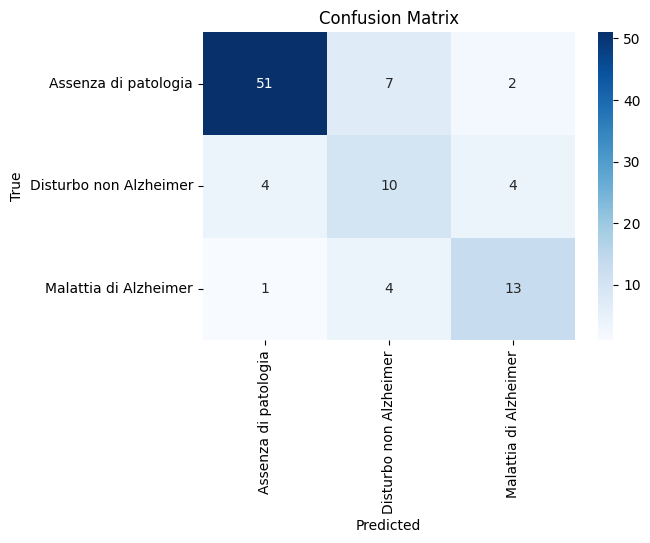

----------------------------------------------------------------------------------------------------

=== Addestramento modello: XGB ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== Best cross-validation scores ===
balanced_accuracy: 0.7145
f1_macro: 0.7130

Best parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}

=== Test set scores ===
Balanced Accuracy: 0.6796
F1 Score (macro): 0.6694
ROC AUC: 0.8273

Classification report:
                         precision    recall  f1-score   support

  Assenza di patologia       0.86      0.82      0.84        60
Disturbo non Alzheimer       0.47      0.50      0.49        18
 Malattia di Alzheimer       0.65      0.72      0.68        18

              accuracy                           0.74        96
             macro avg       0.66      0.68      0.67        96
          weighted avg       0.75 

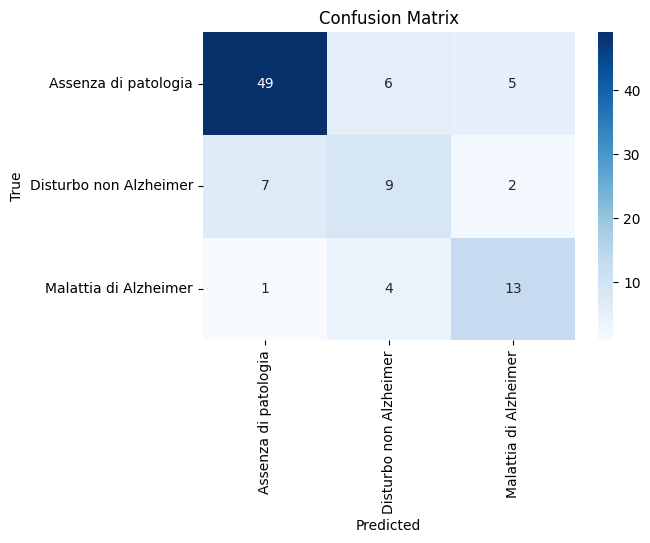

----------------------------------------------------------------------------------------------------


In [9]:
# Dizionario dei modelli e delle loro griglie di parametri
models = {
    'WeightedKNN':{
        'model': KNeighborsClassifier(weights='distance'),
        'param_grid': {
            'classifier__n_neighbors': [3, 5, 7, 9, 11, 13],
            'classifier__metric': ['minkowski', 'euclidean', 'manhattan'],
            'classifier__p': [1, 2],
        }
    },

    'DecisionTree':{
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'param_grid': {
            'classifier__max_depth': [5, 10, 15, None],
            'classifier__min_samples_split': [5, 10, 15],
            'classifier__min_samples_leaf': [2, 4, 8],
            'classifier__criterion': ['gini', 'entropy'],
        }
    },

    'BalancedRandomForest':{
        'model': BalancedRandomForestClassifier(random_state=42, replacement=True),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
        }
    },

    'SVM':{
        'model': SVC(class_weight='balanced', probability=True, random_state=42),
        'param_grid': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf', 'poly'],
        'classifier__gamma': ['scale', 'auto'],  # solo per 'rbf' e 'poly'
        'classifier__degree': [3, 4],  # solo per 'poly'
        }
    },

    'ExtraTrees': {
        'model': ExtraTreesClassifier(random_state=42, class_weight='balanced'),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 150, 200],
            'classifier__max_depth': [None, 5, 10, 15],
            'classifier__min_samples_split': [5, 10, 15],
            'classifier__min_samples_leaf': [1, 2, 4],
        }
    },

    'LGBM':{
        'model': LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 150, 200],
            'classifier__learning_rate':  [0.01, 0.05, 0.1],
            'classifier__max_depth': [-1, 3, 5, 7, 10],
        }
    },

    'CatBoost':{
        'model': None,  # sarà definito nel ciclo
        'param_grid':{
            'classifier__iterations': [300, 500],
            'classifier__depth': [4, 8],
            'classifier__learning_rate': [0.01, 0.05],
        }
    },

    'XGB':{
        'model': None,  # sarà definito nel ciclo
        'param_grid': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 6, 10],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],
        }
    }
}

scoring = {
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'f1_macro': make_scorer(f1_score, average='macro')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ciclo sui modelli
for name, m in models.items():
    print(f"\n=== Addestramento modello: {name} ===")

    # Inizializzazione dinamica dei modelli in base al tipo di classificazione
    if name == 'XGB':
        if is_multiclass:
            model = XGBClassifier(
                objective='multi:softprob',
                num_class=len(np.unique(y_train)),
                eval_metric='mlogloss',
                random_state=42
            )
        else:
            model = XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42
            )
    elif name == 'CatBoost':
        model = CatBoostClassifier(
            loss_function='MultiClass' if is_multiclass else 'Logloss',
            random_seed=42,
            verbose=0
        )
    else:
        model = m['model']

    pipeline = build_pipeline(model)

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=m['param_grid'],
        scoring=scoring,
        refit='balanced_accuracy',
        cv=cv,
        n_jobs=-1,
        verbose=2,
        return_train_score=True,
        error_score='raise'
    )

    # Gestione dell'etichettatura per XGB (richiede label numeriche)
    if name == 'XGB':
        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train)
        y_test_encoded = le.transform(y_test)

        search.fit(X_train, y_train_encoded)

        class_labels = le.classes_
        evaluate_model(search, X_test, y_test, class_labels, le=le, is_multiclass=is_multiclass)

    else:
        search.fit(X_train, y_train)
        class_labels = search.best_estimator_.named_steps['classifier'].classes_
        evaluate_model(search, X_test, y_test, class_labels, is_multiclass=is_multiclass)

    print("-"*100)
